In [29]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.stats.api as sms
import seaborn as sns
import matplotlib.pyplot as plt

# 載入原始資料集（透過相對路徑從 notebooks 回到根目錄，再進入 data/raw）
df_raw = pd.read_csv('../data/raw/YRBS_2007.csv')

# 檢查資料是否成功載入
print(f"【系統確認】資料載入成功！")
print(f"原始資料大小：共有 {df_raw.shape[0]} 筆學生填答，包含 {df_raw.shape[1]} 個欄位變數。")

【系統確認】資料載入成功！
原始資料大小：共有 14041 筆學生填答，包含 103 個欄位變數。


In [36]:
# 1. 篩選出 Question 4 規定的性別與體重變數，並排除 NaN 欄位
df_weight_analysis = df_raw[['WhatIsYourSex', 'HowMuchDoYouWeighWithoutShoesInKG']].dropna().copy()

# 2. 強制將體重轉換為數值型態（確保沒有干擾分析的雜質文字）
df_weight_analysis['HowMuchDoYouWeighWithoutShoesInKG'] = pd.to_numeric(
    df_weight_analysis['HowMuchDoYouWeighWithoutShoesInKG'], errors='coerce'
)
df_weight_analysis = df_weight_analysis.dropna()

# 3. 【深入過濾】排除 YRBS 的隱藏異常代碼（例如 99.99 這種代表 Skip/Missing 的值）
# 根據青少年生理常態，將體重嚴格篩選在合理的 30 kg 至 90 kg 之間
df_weight_cleaned = df_weight_analysis[
    (df_weight_analysis['HowMuchDoYouWeighWithoutShoesInKG'] >= 30) & 
    (df_weight_analysis['HowMuchDoYouWeighWithoutShoesInKG'] < 90)
].copy()

# 4. 定義男女生群組（根據原始編碼：1 = Male, 2 = Female）
male_w = df_weight_cleaned[df_weight_cleaned['WhatIsYourSex'] == 1]['HowMuchDoYouWeighWithoutShoesInKG']
female_w = df_weight_cleaned[df_weight_cleaned['WhatIsYourSex'] == 2]['HowMuchDoYouWeighWithoutShoesInKG']

# 5. 印出清洗後的初步統計結果來驗證
print("【主問題：體重資料清洗結果】")
print(f"男生有效樣本數: {len(male_w)} 人，平均體重: {male_w.mean():.2f} kg")
print(f"女生有效樣本數: {len(female_w)} 人，平均體重: {female_w.mean():.2f} kg")

# 將主問題清洗後的資料儲存到 data/processed/ 資料夾，符合專案規範
df_weight_cleaned.to_csv('../data/processed/cleaned_weight_data.csv', index=False)
print("\n[系統確認] 洗清後的體重資料已成功儲存至 data/processed/cleaned_weight_data.csv")

【主問題：體重資料清洗結果】
男生有效樣本數: 6166 人，平均體重: 60.23 kg
女生有效樣本數: 5510 人，平均體重: 68.70 kg

[系統確認] 洗清後的體重資料已成功儲存至 data/processed/cleaned_weight_data.csv


In [42]:
# 1. 篩選出 Question 5 規定的性別與身高變數，並排除 NaN 欄位
df_height_analysis = df_raw[['WhatIsYourSex', 'HowTallAreYouWithoutShoesInMeters']].dropna().copy()

# 2. 強制將身高轉換為數值型態（確保沒有雜質文字）
df_height_analysis['HowTallAreYouWithoutShoesInMeters'] = pd.to_numeric(
    df_height_analysis['HowTallAreYouWithoutShoesInMeters'], errors='coerce'
)
df_height_analysis = df_height_analysis.dropna()

# 3. 【延伸深入過濾】排除身高的隱藏異常代碼（例如 9.99 這種代表 Skip/Missing 的值）
# 根據青少年生理常態，將身高嚴格篩選在合理的 1.0 m 至 2.2 m 之間
df_height_cleaned = df_height_analysis[
    (df_height_analysis['HowTallAreYouWithoutShoesInMeters'] >= 1.0) & 
    (df_height_analysis['HowTallAreYouWithoutShoesInMeters'] < 2.2)
].copy()

# 4. 定義男女生群組（1 = Male, 2 = Female）
male_h = df_height_cleaned[df_height_cleaned['WhatIsYourSex'] == 1]['HowTallAreYouWithoutShoesInMeters']
female_h = df_height_cleaned[df_height_cleaned['WhatIsYourSex'] == 2]['HowTallAreYouWithoutShoesInMeters']

# 5. 印出清洗後的初步統計結果來驗證
print("【延伸問題：身高資料清洗結果】")
print(f"男生有效樣本數: {len(male_h)} 人，平均身高: {male_h.mean():.2f} m")
print(f"女生有效樣本數: {len(female_h)} 人，平均身高: {female_h.mean():.2f} m")

# 將延伸問題清洗後的資料儲存到 data/processed/ 資料夾，符合專案規範
df_height_cleaned.to_csv('../data/processed/cleaned_height_data.csv', index=False)
print("\n[系統確認] 洗清後的身高資料已成功儲存至 data/processed/cleaned_height_data.csv")

【延伸問題：身高資料清洗結果】
男生有效樣本數: 6490 人，平均身高: 1.63 m
女生有效樣本數: 6572 人，平均身高: 1.76 m

[系統確認] 洗清後的身高資料已成功儲存至 data/processed/cleaned_height_data.csv


In [47]:
# 1. 建立包含主問題（體重）與延伸問題（身高）的綜合摘要 DataFrame
summary_df = pd.DataFrame({
    'Analysis Type': ['Weight (kg)', 'Weight (kg)', 'Height (m)', 'Height (m)'],
    'Gender Group': ['Male', 'Female', 'Male', 'Female'],
    'Sample Size (n)': [len(male_w), len(female_w), len(male_h), len(female_h)],
    'Mean Value': [male_w.mean(), female_w.mean(), male_h.mean(), female_h.mean()],
    'Std Dev': [male_w.std(), female_w.std(), male_h.std(), female_h.std()]
})

# 2. 在畫面上印出表格，方便檢查
print("=" * 60)
print("--- 專案雙變數敘述統計摘要表 ---")
print("=" * 60)
print(summary_df.to_string(index=False))
print("=" * 60)

# 3. 自動導出至 Cookiecutter 規範的指定路徑
summary_df.to_csv('../outputs/tables/project_summary_table.csv', index=False)
print("\n[系統確認] 摘要統計表已成功儲存至 outputs/tables/project_summary_table.csv")

--- 專案雙變數敘述統計摘要表 ---
Analysis Type Gender Group  Sample Size (n)  Mean Value   Std Dev
  Weight (kg)         Male             6166   60.228046 10.254236
  Weight (kg)       Female             5510   68.698920 10.227382
   Height (m)         Male             6490    1.629911  0.073767
   Height (m)       Female             6572    1.757365  0.083771

[系統確認] 摘要統計表已成功儲存至 outputs/tables/project_summary_table.csv


In [51]:
# ==============================================================================
# 1. 主問題（體重 Weight）的推論統計計算
# ==============================================================================
# 執行 Welch's t-test (設定 equal_var=False)
t_stat_w, p_val_w = stats.ttest_ind(male_w, female_w, equal_var=False)

# 計算男女生平均體重的樣本差值 (點估計)
mean_diff_w = male_w.mean() - female_w.mean()

# 使用 statsmodels 計算 Welch's t-test 對應的 95% 信賴區間 (Confidence Interval)
cm_w = sms.CompareMeans(sms.DescrStatsW(male_w), sms.DescrStatsW(female_w))
ci_low_w, ci_upp_w = cm_w.tconfint_diff(alpha=0.05, usevar='unequal')


# ==============================================================================
# 2. 延伸問題（身高 Height）的推論統計計算
# ==============================================================================
# 執行 Welch's t-test (設定 equal_var=False)
t_stat_h, p_val_h = stats.ttest_ind(male_h, female_h, equal_var=False)

# 計算男女生平均身高的樣本差值 (點估計)
mean_diff_h = male_h.mean() - female_h.mean()

# 使用 statsmodels 計算身高的 95% 信賴區間
cm_h = sms.CompareMeans(sms.DescrStatsW(male_h), sms.DescrStatsW(female_h))
ci_low_h, ci_upp_h = cm_h.tconfint_diff(alpha=0.05, usevar='unequal')


# ==============================================================================
# 3. 輸出推論統計報告
# ==============================================================================
print("=" * 60)
print("--- 雙樣本推論統計檢定結果 (Welch's t-test) ---")
print("=" * 60)

print("【Q4 主問題：男女學生體重比較】")
print(f"  * 樣本平均數差值 (Male - Female): {mean_diff_w:.4f} kg")
print(f"  * 差值的 95% 信賴區間 (95% CI): [{ci_low_w:.4f}, {ci_upp_w:.4f}] kg")
print(f"  * 檢定統計量 (t-statistic): {t_stat_w:.4f}")
# 用科學記號顯示 P-value，方便觀察極小值
print(f"  * 顯著性機率 (P-value): {p_val_w:.4e}") 

print("\n【Q5 延伸問題：男女學生身高比較】")
print(f"  * 樣本平均數差值 (Male - Female): {mean_diff_h:.4f} m")
print(f"  * 差值的 95% 信賴區間 (95% CI): [{ci_low_h:.4f}, {ci_upp_h:.4f}] m")
print(f"  * 檢定統計量 (t-statistic): {t_stat_h:.4f}")
print(f"  * 顯著性機率 (P-value): {p_val_h:.4e}")
print("=" * 60)

--- 雙樣本推論統計檢定結果 (Welch's t-test) ---
【Q4 主問題：男女學生體重比較】
  * 樣本平均數差值 (Male - Female): -8.4709 kg
  * 差值的 95% 信賴區間 (95% CI): [-8.8430, -8.0988] kg
  * 檢定統計量 (t-statistic): -44.6227
  * 顯著性機率 (P-value): 0.0000e+00

【Q5 延伸問題：男女學生身高比較】
  * 樣本平均數差值 (Male - Female): -0.1275 m
  * 差值的 95% 信賴區間 (95% CI): [-0.1302, -0.1247] m
  * 檢定統計量 (t-statistic): -92.3129
  * 顯著性機率 (P-value): 0.0000e+00


In [52]:
# 1. 載入並初步剔除 NaN
df_height = df_raw[['WhatIsYourSex', 'HowTallAreYouWithoutShoesInMeters']].dropna().copy()
df_height['HowTallAreYouWithoutShoesInMeters'] = pd.to_numeric(df_height['HowTallAreYouWithoutShoesInMeters'], errors='coerce')
df_height = df_height.dropna()

# 2. 【延伸變數深入清洗】在 YRBS 中身高大於等於 3 公尺的數值通常為填答錯誤或無效代碼
# 依生理常態，篩選身高在 1.0 m 到 2.2 m 之間的合理範圍
df_height_cleaned = df_height[
    (df_height['HowTallAreYouWithoutShoesInMeters'] >= 1.0) & 
    (df_height['HowTallAreYouWithoutShoesInMeters'] < 2.2)
].copy()

male_h = df_height_cleaned[df_height_cleaned['WhatIsYourSex'] == 1]['HowTallAreYouWithoutShoesInMeters']
female_h = df_height_cleaned[df_height_cleaned['WhatIsYourSex'] == 2]['HowTallAreYouWithoutShoesInMeters']

# 3. 執行身高的 Welch's t-test
t_stat_h, p_val_h = stats.ttest_ind(male_h, female_h, equal_var=False)

print("--- 延伸問題：男女身高推論統計結果 ---")
print(f"有效男生人數: {len(male_h)}，平均身高: {male_h.mean():.2f} m")
print(f"有效女生人數: {len(female_h)}，平均身高: {female_h.mean():.2f} m")
print(f"身高 Welch's t 檢定值: {t_stat_h:.4f}，P-value: {p_val_h:.4e}")

--- 延伸問題：男女身高推論統計結果 ---
有效男生人數: 6490，平均身高: 1.63 m
有效女生人數: 6572，平均身高: 1.76 m
身高 Welch's t 檢定值: -92.3129，P-value: 0.0000e+00


C:\Users\asdfg\AppData\Local\Temp\ipykernel_16040\2794732135.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='WhatIsYourSex', y='HowMuchDoYouWeighWithoutShoesInKG', data=df_weight_cleaned, palette='pastel')


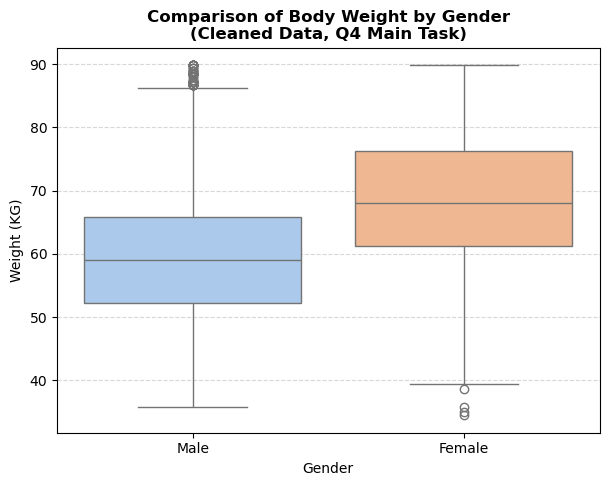

[系統提示] 圖一 (weight_boxplot_cleaned.png) 已成功儲存！


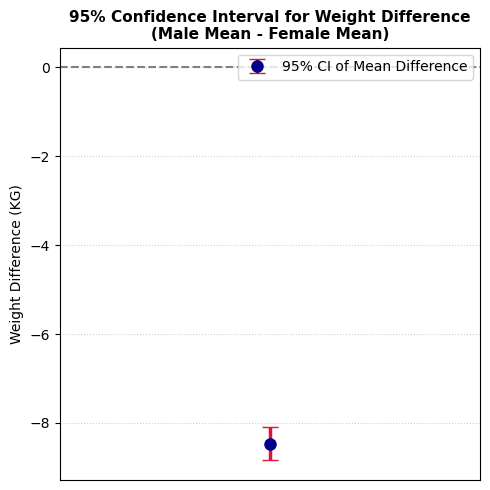

[系統提示] 圖二 (weight_diff_CI_plot.png) 已成功儲存！


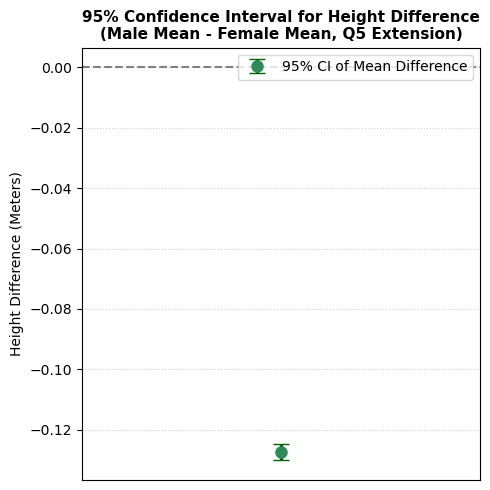

[系統提示] 圖三 (height_diff_CI_plot.png) 已成功儲存！

【專案程式部分全部跑通！】所有統計圖表皆已順利導出。


In [55]:
# ==============================================================================
# 1. 繪製圖一：主問題（體重）的男女群組對比箱形圖（敘述統計圖）
# ==============================================================================
plt.figure(figsize=(7, 5))
sns.boxplot(x='WhatIsYourSex', y='HowMuchDoYouWeighWithoutShoesInKG', data=df_weight_cleaned, palette='pastel')
plt.xticks([0, 1], ['Male', 'Female'])
plt.title('Comparison of Body Weight by Gender\n(Cleaned Data, Q4 Main Task)', fontsize=12, fontweight='bold')
plt.xlabel('Gender', fontsize=10)
plt.ylabel('Weight (KG)', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 自動儲存至 outputs/figures/ [cite: 148, 149, 178]
plt.savefig('../outputs/figures/weight_boxplot_cleaned.png', dpi=300)
plt.show()
print("[系統提示] 圖一 (weight_boxplot_cleaned.png) 已成功儲存！")


# ==============================================================================
# 2. 繪製圖二：主問題（體重差值）的 95% 信賴區間圖（推論統計圖）
# ==============================================================================
plt.figure(figsize=(5, 5))
plt.errorbar(x=0, y=mean_diff_w, yerr=[[mean_diff_w - ci_low_w], [ci_upp_w - mean_diff_w]], 
             fmt='o', color='darkblue', ecolor='crimson', capsize=6, elinewidth=2.5, markersize=8,
             label='95% CI of Mean Difference')

plt.axhline(0, color='gray', linestyle='--')
plt.title('95% Confidence Interval for Weight Difference\n(Male Mean - Female Mean)', fontsize=11, fontweight='bold')
plt.ylabel('Weight Difference (KG)', fontsize=10)
plt.xticks([]) 
plt.xlim(-0.5, 0.5)
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()

# 自動儲存至 outputs/figures/ [cite: 148, 149, 178]
plt.savefig('../outputs/figures/weight_diff_CI_plot.png', dpi=300)
plt.show()
print("[系統提示] 圖二 (weight_diff_CI_plot.png) 已成功儲存！")


# ==============================================================================
# 3. 繪製圖三：延伸問題（身高差值）的 95% 信賴區間圖（延伸推論統計圖）
# ==============================================================================
plt.figure(figsize=(5, 5))
plt.errorbar(x=0, y=mean_diff_h, yerr=[[mean_diff_h - ci_low_h], [ci_upp_h - mean_diff_h]], 
             fmt='o', color='seagreen', ecolor='darkgreen', capsize=6, elinewidth=2.5, markersize=8,
             label='95% CI of Mean Difference')

plt.axhline(0, color='gray', linestyle='--')
plt.title('95% Confidence Interval for Height Difference\n(Male Mean - Female Mean, Q5 Extension)', fontsize=11, fontweight='bold')
plt.ylabel('Height Difference (Meters)', fontsize=10) # <-- 這裡幫你修正補齊了！
plt.xticks([]) 
plt.xlim(-0.5, 0.5)
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()

# 自動儲存至 outputs/figures/ [cite: 148, 149, 178]
plt.savefig('../outputs/figures/height_diff_CI_plot.png', dpi=300)
plt.show()
print("[系統提示] 圖三 (height_diff_CI_plot.png) 已成功儲存！")

print("\n" + "="*60 + "\n【專案程式部分全部跑通！】所有統計圖表皆已順利導出。" + "\n" + "="*60)